## **Exercise 1: Duplicate Detection and Removal**

In [50]:
#Loading
import pandas as pd
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [51]:
#Duplicate check
duplicates = df.duplicated().any()
print('Presence of duplicates:', duplicates)

Presence of duplicates: False


## **Exercise 2: Handling Missing Values**

In [44]:
df = pd.read_csv('train.csv')
print('Empty cells per column:')
print(df.isnull().sum())

Empty cells per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Age: 177 empty cells  
Cabin: 687 empty cells  
Embarked: 2 empty cells

In [45]:
total_rows = df.shape[0]
print('Total rows =', total_rows)

Total rows = 891


In [46]:
empty_cells_before = df.isnull().sum()
print(empty_cells_before)
missing_pct = df['Age'].isnull().mean() * 100
print(f"Missing data for column 'Age': {missing_pct:.2f}%")
# % of missing values for 'Age' is around 20%, imputation will be used. Median imputation preferred as it is more stable to outliers
missing_pct = df['Cabin'].isnull().mean() * 100
print(f"Missing data for column 'Cabin': {missing_pct:.2f}%")
# % of missing values for 'Cabin' is around 77%, dropping the column will be preferred for now so as to reduce noise in data

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Missing data for column 'Age': 19.87%
Missing data for column 'Cabin': 77.10%


In [47]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df = df.drop(columns='Cabin')
df = df.dropna(subset=['Embarked'])
empty_cells_after = df.isnull().sum()
print(empty_cells_after)
len(df)

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


889

## **Exercise 3: Feature Engineering**

**Using the following formula, we can create feature: 'Family Size'**  
Family Size = SibSp + Parch

In [52]:
df['Family Size'] = df['SibSp'] + df['Parch']

Since title are usually followed by a dot in the name, we can extract the title from the 'Name' column using string manipulation techniques

In [53]:
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

In [54]:
df.to_csv('updated_train.csv', index=False)
df = pd.read_csv('updated_train.csv')

## **Exercise 4: Outlier Detection and Handling**

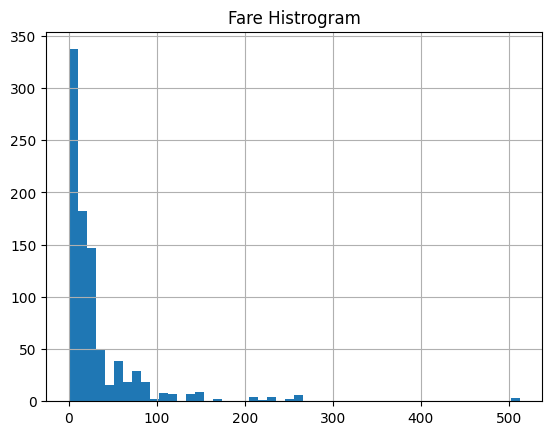

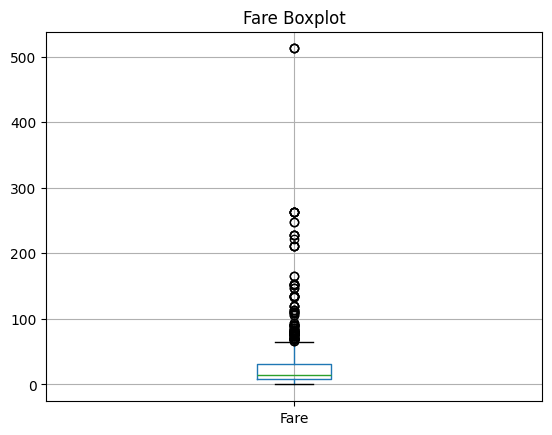

In [55]:
import matplotlib.pyplot as plt
df['Fare'].hist(bins=50)
plt.title('Fare Histrogram')
plt.show()
df.boxplot(column=['Fare'])
plt.title('Fare Boxplot')
plt.show()

**Outlier Detection: IQR Method**

In [56]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [57]:
outliers = df[(df['Fare'] < lower_bound) | (df['Fare'] > upper_bound)]
num_outliers= len(outliers)
print('Number of outliers within column "Fare":', num_outliers)

Number of outliers within column "Fare": 116


**Outlier Handling: Quantile Capping (Winsorization)**  
Upper: 0.98  
Lower: 0.02

In [58]:
initial_fare = df['Fare'].describe()
print('Fare BEFORE capping:', initial_fare)

Fare BEFORE capping: count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


In [59]:
fare_lower = df['Fare'].quantile(0.02)
fare_upper = df['Fare'].quantile(0.98)
df['Fare'] = df['Fare'].clip(fare_lower, fare_upper)
print('Fare AFTER capping')
print(df['Fare'].describe())

Fare AFTER capping
count    891.00000
mean      30.79061
std       39.82766
min        6.39750
25%        7.91040
50%       14.45420
75%       31.00000
max      211.33750
Name: Fare, dtype: float64


**Outlier Handling: Log transformation**

In [60]:
import numpy as np
df['Fare_log'] = np.log(df['Fare'])

**Outlier Handling: Row removal**  
This was not used due to the size of the dataset (being already small) and the risk of losing essential information and thus reducing already limited data

## **Exercise 5: Data Normalization**

**Goal:** Scale numerical features to prepare for modeling.

Use StandardScaler (mean = 0, std = 1) for normally distributed features.  
Use MinMaxScaler (range [0, 1]) for features that are skewed or bounded.  

**Important:** Perform this step after outlier treatment to avoid distortion caused by extreme values.

In [62]:
from sklearn.preprocessing import MinMaxScaler
fare_scaler = MinMaxScaler()
df['Fare'] = fare_scaler.fit_transform(df[['Fare']])
df[['Fare']].head()

,Fare
0,0.004160
1,0.316609
2,0.007453
3,0.227884
4,0.008063


## **Exercise 6: Feature Encoding**

**Goal:** Finalize categorical variable encoding.  

Identify remaining categorical columns (e.g. Sex, Embarked, Title).  

**Apply:**  
1. One-Hot Encoding for nominal variables.  
1. Label Encoding if any ordinal variables remain.  

Merge encoded columns back into the main dataset.

**Reminder:** Encoding comes after handling missing values and outliers, but before scaling (if applicable).

In [63]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family Size,Title,Fare_log
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,0.004160,NaN,S,1,Mr,1.981001
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,0.316609,C85,C,1,Mrs,4.266662
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,0.007453,NaN,S,0,Miss,2.070022
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,0.227884,C123,S,1,Mrs,3.972177
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,0.008063,NaN,S,0,Mr,2.085672


**Categorical columns:**
1. Pclass
1. Sex
1. Embarked
1. Title

Column: Pclass  
Encoding: Ordinal

Column: Sex  
Encoding: One-Hot  

Column: Embarked  
Encoding: One-Hot  

Column: Title  
Encoding: Ordinal

In [64]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

**Encoding relevant columns**

In [65]:
ordinal_cols = ['Pclass', 'Title']
one_hot_cols = ['Sex', 'Embarked']
column_transform = ColumnTransformer(
    transformers=[
        ("oe", OrdinalEncoder(), ordinal_cols),
        ("ohe", OneHotEncoder(), one_hot_cols)
    ],
    remainder='drop'
)

**Fit + Transform + Merge**

In [66]:
encoded = column_transform.fit_transform(df)
encoded_cols = column_transform.get_feature_names_out()
df_encoded = pd.DataFrame(encoded, columns=encoded_cols, index=df.index)
df_final = pd.concat([df, df_encoded], axis=1)
df_final.to_csv("processed_dataset.csv", index=False)
df_final.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Title,Fare_log,oe__Pclass,oe__Title,ohe__Sex_female,ohe__Sex_male,ohe__Embarked_C,ohe__Embarked_Q,ohe__Embarked_S,ohe__Embarked_nan
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,0.004160,...,Mr,1.981001,2.0,12.0,0.0,1.0,0.0,0.0,1.0,0.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,0.316609,...,Mrs,4.266662,0.0,13.0,1.0,0.0,1.0,0.0,0.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,0.007453,...,Miss,2.070022,2.0,9.0,1.0,0.0,0.0,0.0,1.0,0.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,0.227884,...,Mrs,3.972177,0.0,13.0,1.0,0.0,0.0,0.0,1.0,0.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,0.008063,...,Mr,2.085672,2.0,12.0,0.0,1.0,0.0,0.0,1.0,0.0


## **Exercise 7: Data Transformation for Age Feature**

In [67]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [68]:
df['Age'].isna().any()

np.True_

**Since empty values for 'Age' was detected earlier:**

In [69]:
df = df.dropna(subset=['Age'])
len(df['Age'])

714

In [70]:
df['LifeStage'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 60, 120],
    labels=['Child', 'Teen', 'Adult', 'Senior']
)
df.to_csv('age_feature.csv', index=False)
df = pd.read_csv('age_feature.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,LifeStage
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Adult


In [71]:
df_encoded = pd.get_dummies(df, columns=['LifeStage'])
df_encoded.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,LifeStage_Adult,LifeStage_Child,LifeStage_Senior,LifeStage_Teen
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,True,False,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,True,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,True,False,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,True,False,False,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,True,False,False,False


In [72]:
df.to_csv('age_feature.csv', index=False)